# 04 - Model 3 with the Version A window (proposal predictors, leaky)

Exactly the proposal predictor set (8 climate features + spring type, VIF screening inside the
pipeline) but with the label-conditional Version A window. Its near-perfect score is the result that
prompted the leakage investigation. Re-run of `archive/random_forest_proposal_compliant_model.ipynb`
with the 2009-2023 survey-year window and shuffled cross-validation.

In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))  # run from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from spring_drying.config import (FIGURES_DIR, TABLES_DIR, RANDOM_STATE, WINDOW_END, WINDOW_LEN,
                                  SURVEY_YEAR, ERA5_LAND_FIRST_YEAR, RAW_SURVEY_PATH, NC_PATH)
from spring_drying.data import load_springs, attach_drying_reason

sns.set_style("whitegrid")
pd.set_option("display.width", 140)

def save_json(obj, name):
    def conv(o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, (np.ndarray,)): return o.tolist()
        raise TypeError(type(o))
    with open(TABLES_DIR / name, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=conv)
    print("saved", TABLES_DIR / name)

from spring_drying.climate import FEATURE_COLS
from spring_drying.modeling import make_rf, make_model3
from spring_drying.experiments import run_experiment, print_result

springs = load_springs()
base = springs.drop(columns=FEATURE_COLS + ["Perennial / Seasonal"])  # CSV climate columns unused; text label replaced by 0/1
ASPECT = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
ROADS = [f"Road-{a}" for a in ASPECT]
ASPECT_1HOT = [f"Aspect-{a}" for a in ASPECT]

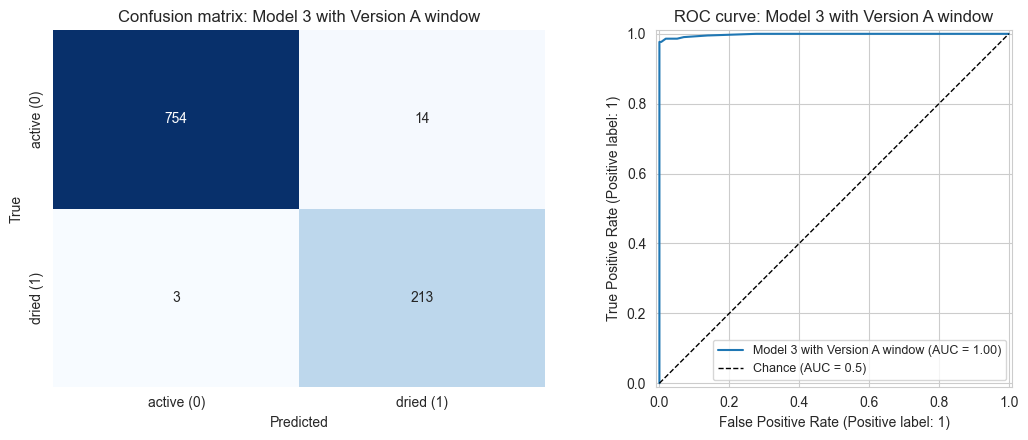

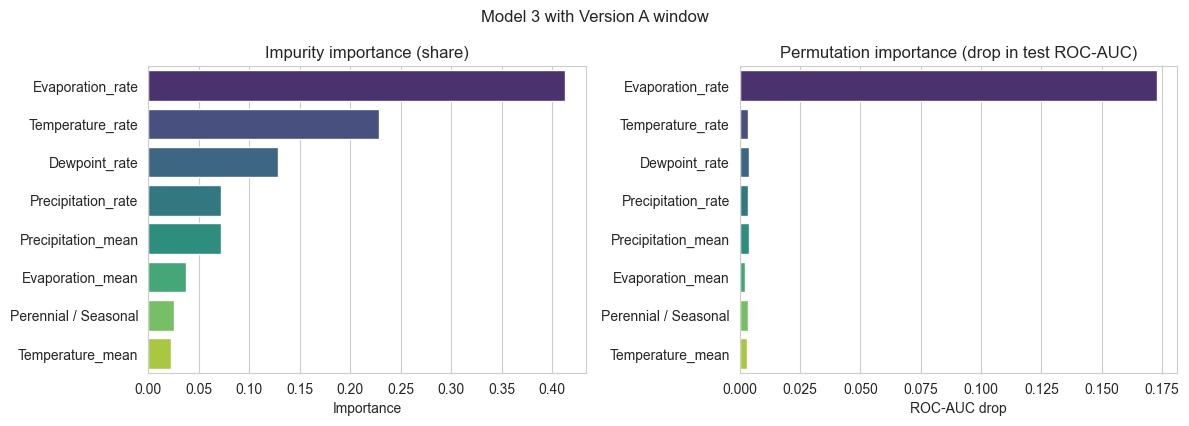

Model 3 with Version A window  (n = 3278, dried = 718, test = 984)
  test: accuracy 0.983, precision 0.938, recall 0.986, f1 0.962, roc_auc 0.998
  confusion: TN 754  FP 14  FN 3  TP 213
  5-fold CV (shuffled): F1 0.974 +/- 0.014, AUC 0.992 +/- 0.004
  VIF dropped: [['Dewpoint_mean', 50.19]]


In [2]:
version_a = pd.read_csv(TABLES_DIR / "climate_features_version_a.csv")
data = pd.concat([base.reset_index(drop=True), version_a], axis=1).rename(columns={"perennial": "Perennial / Seasonal"})
features = FEATURE_COLS + ["Perennial / Seasonal"]
valid = data[features].notna().all(axis=1)
result, model = run_experiment("model3_version_a", "Model 3 with Version A window",
                               data.loc[valid, features], data.loc[valid, "dried"].values, make_model3())
print_result(result)